In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Load the datasets
df_videos = pd.read_csv('data/videos-stats.csv')
df_comments = pd.read_csv('data/comments.csv')

# --- DATA CLEANING ---
# Filter out hidden metrics (-1)
df_clean = df_videos[(df_videos['Likes'] != -1) & (df_videos['Comments'] != -1)].copy()

# Calculate Engagement Rate (Likes per 100 Views)
df_clean['Engagement_Rate'] = (df_clean['Likes'] / df_clean['Views']) * 100

# Convert Published At to datetime and extract year
df_clean['Published At'] = pd.to_datetime(df_clean['Published At'])
df_clean['Year'] = df_clean['Published At'].dt.year


C:\Users\Professional\AppData\Local\Temp\ipykernel_6948\3754717970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_views.values, y=top_views.index, palette='viridis')


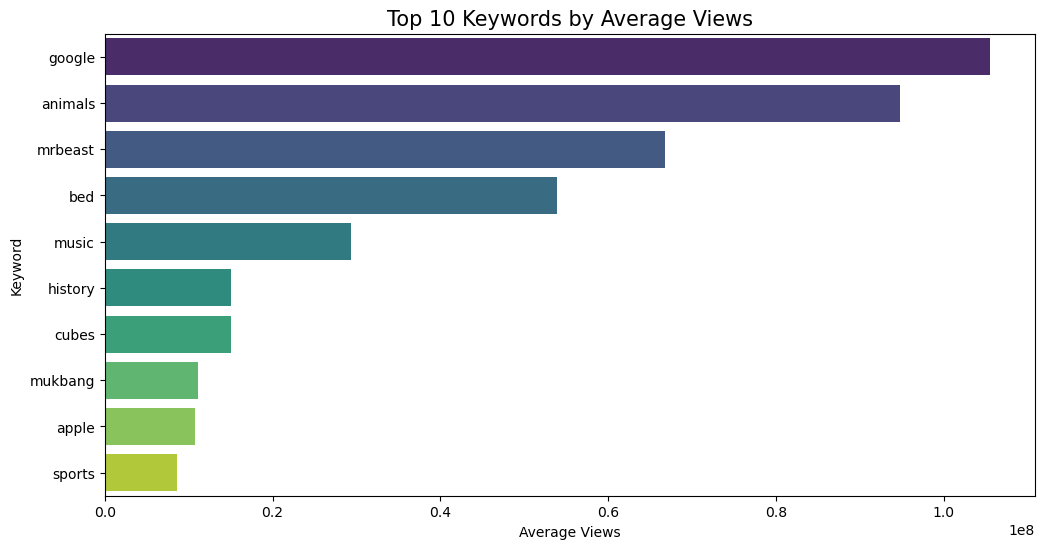

In [5]:

# --- VISUALIZATION 1: Top 10 Keywords by Average Views ---
plt.figure(figsize=(12, 6))
top_views = df_clean.groupby('Keyword')['Views'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_views.values, y=top_views.index, palette='viridis')
plt.title('Top 10 Keywords by Average Views', fontsize=15)
plt.xlabel('Average Views')
plt.ylabel('Keyword')
plt.savefig('visuals/top_keywords_views.png')


C:\Users\Professional\AppData\Local\Temp\ipykernel_6948\79370243.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_eng.values, y=top_eng.index, palette='magma')


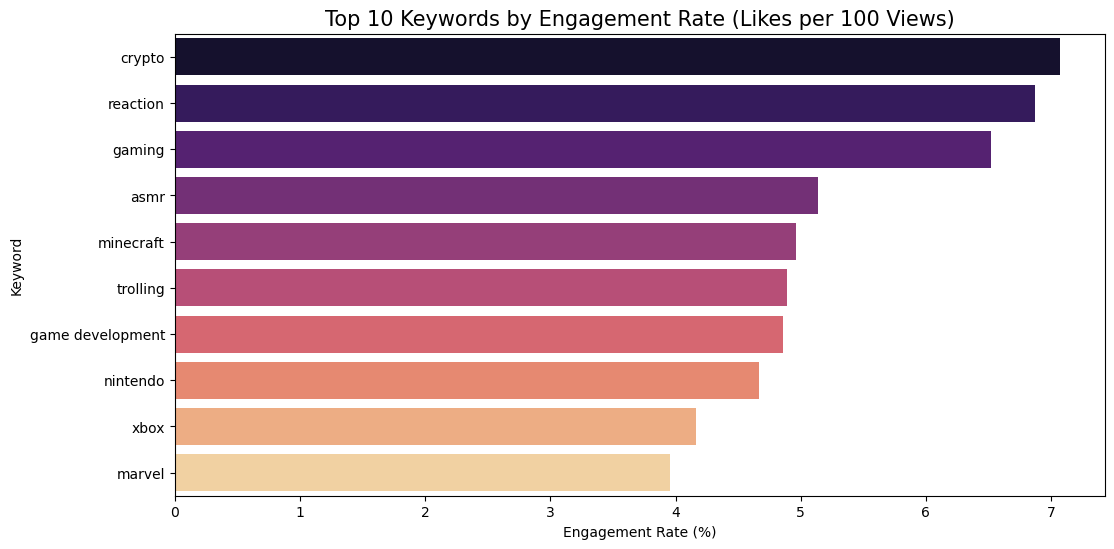

In [6]:

# --- VISUALIZATION 2: Engagement Rate by Keyword (Efficiency) ---
plt.figure(figsize=(12, 6))
top_eng = df_clean.groupby('Keyword')['Engagement_Rate'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_eng.values, y=top_eng.index, palette='magma')
plt.title('Top 10 Keywords by Engagement Rate (Likes per 100 Views)', fontsize=15)
plt.xlabel('Engagement Rate (%)')
plt.savefig('visuals/engagement_rate.png')


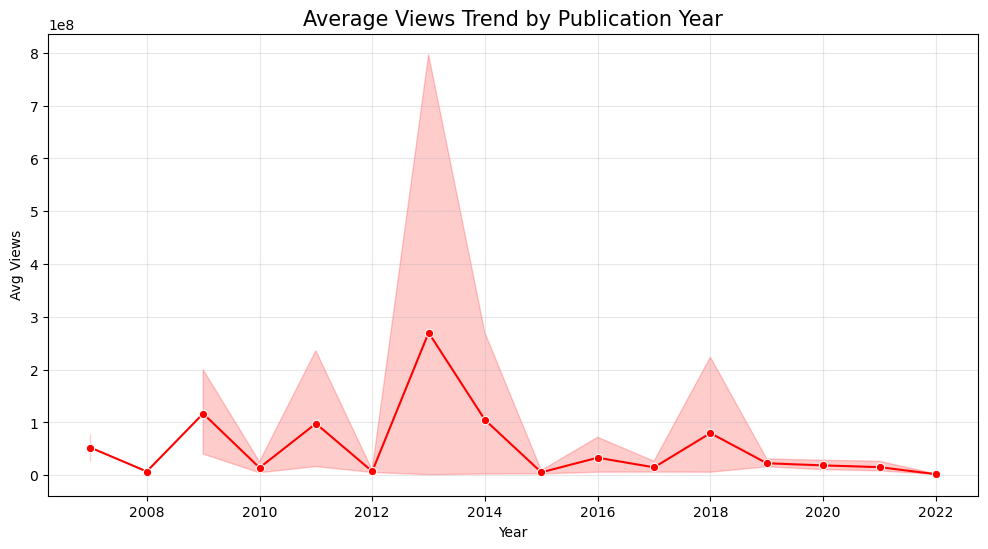

In [7]:

# --- VISUALIZATION 3: Performance Over Time (Views vs. Year) ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='Year', y='Views', estimator='mean', marker='o', color='red')
plt.title('Average Views Trend by Publication Year', fontsize=15)
plt.ylabel('Avg Views')
plt.grid(True, alpha=0.3)
plt.savefig('visuals/trends_over_time.png')


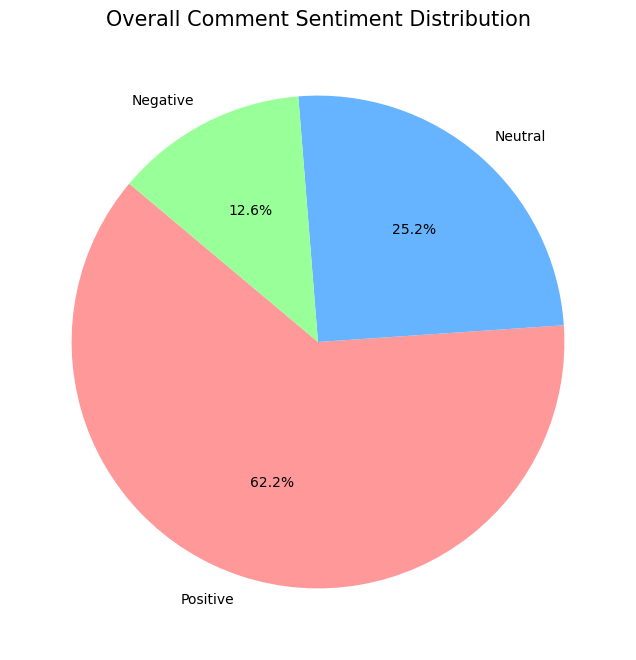

In [8]:

# --- VISUALIZATION 4: Sentiment Distribution (Pie Chart) ---
# Merging for Sentiment Analysis
df_merged = pd.merge(df_comments, df_videos[['Video ID', 'Keyword']], on='Video ID')
sentiment_counts = df_merged['Sentiment'].replace({0: 'Negative', 1: 'Neutral', 2: 'Positive'}).value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title('Overall Comment Sentiment Distribution', fontsize=15)
plt.savefig('visuals/sentiment_distribution.png')


C:\Users\Professional\AppData\Local\Temp\ipykernel_6948\2043356900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_videos, x='Status', y='Views', estimator='mean', palette='Set2')


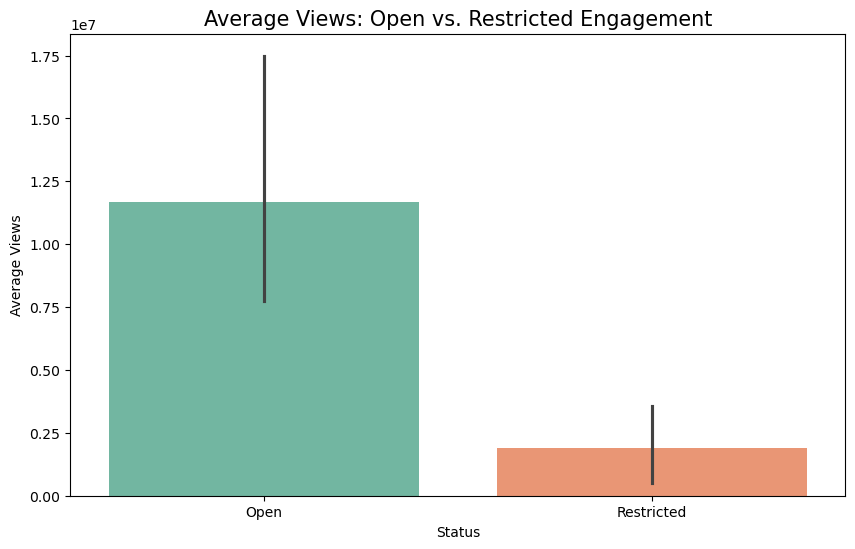

In [9]:

# --- VISUALIZATION 5: Open vs. Restricted Engagement ---
df_videos['Status'] = df_videos.apply(lambda x: 'Restricted' if x['Likes'] == -1 or x['Comments'] == -1 else 'Open', axis=1)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_videos, x='Status', y='Views', estimator='mean', palette='Set2')
plt.title('Average Views: Open vs. Restricted Engagement', fontsize=15)
plt.ylabel('Average Views')
plt.savefig('visuals/engagement_status_comparison.png')
